In [1]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm

In [2]:
data = pd.read_csv("../data/preprocessed/Event_traces.csv")

In [3]:
success_non_dup_data = data[data["Label"] == "Success"].drop_duplicates(subset=['Features'])
fail_non_dup_data = data[data["Label"] == "Fail"].drop_duplicates(subset=['Features'])

In [4]:
data = pd.merge(success_non_dup_data, fail_non_dup_data, how="outer").reset_index(drop=True)

In [5]:
# # Drop 30% of 'Success' rows to reduce memory consumption
# success_idx = (
#     data.loc[data["Label"] == "Success"]
#         .sample(frac=0.40, random_state=42)
#         .index
# )
# data = data.drop(success_idx).reset_index(drop=True)

In [6]:
# convert string sequence to list sequence
data["Features"] = data["Features"].map(lambda x: x[1:-1].split(","))

# can map timeinterval with the operation ran
data["TimeInterval"] = data["TimeInterval"].map(lambda x: [float(i) for i in x[1:-1].split(",")])

In [7]:
data["Features"]

0        [E5, E22, E5, E5, E26, E26, E26, E11, E9, E11,...
1        [E5, E5, E22, E5, E11, E9, E11, E9, E26, E26, ...
2        [E22, E5, E5, E5, E26, E26, E26, E11, E9, E11,...
3        [E22, E5, E5, E5, E26, E26, E9, E11, E9, E11, ...
4        [E22, E5, E5, E5, E11, E9, E11, E9, E11, E9, E...
                               ...                        
18378    [E22, E5, E5, E5, E26, E26, E26, E11, E9, E11,...
18379    [E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...
18380    [E22, E5, E5, E5, E26, E26, E26, E11, E9, E9, ...
18381    [E5, E5, E5, E22, E11, E9, E11, E9, E11, E9, E...
18382    [E22, E5, E5, E5, E26, E26, E26, E11, E9, E11,...
Name: Features, Length: 18383, dtype: object

In [8]:
# One-Hot Encoding

from sklearn.preprocessing import OneHotEncoder

unique_features = data["Features"].map(lambda x: [i[1:] for i in x]).explode().unique().astype(np.int32)
unique_features.sort()

encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)
encoded_features = encoder.fit(unique_features.reshape(-1, 1))

data["Features_Encoded"] = data["Features"].map(lambda x: encoder.transform([[int(i[1:])] for i in x]))

In [9]:
# clean data to reduce memory usage
data = data[["Features_Encoded", "TimeInterval", "Label"]]

In [10]:
data

,Features_Encoded,TimeInterval,Label
0,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[1.0, 1.0, 1.0, 38.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
1,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 41.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 2.0, 0.0, 41.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[1.0, 0.0, 0.0, 50.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
...,...,...,...
18378,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 1.0, 161.0, 0.0, 0.0, 0.0, 0.0, 0.0...",Fail
18379,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Fail
18380,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[1.0, 0.0, 3.0, 47.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
18381,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 42.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Fail


In [11]:
# Maximum length of sequence is chosen as 50 based on the distribution of sequence lengths
# Sequences beyond this length are rare and has drippled effect on buiding even sequences
# (i.e., padding/truncating) for training. Most short or medium sequences from 1 -> 40 in
# length are padded up to 200s if this maximum length is not chosen.

MAX_LEN = 50 # maximum sequence length
ENCODED_DIMEN = data["Features_Encoded"].iloc[0].shape[1]  # for 'one-hot' encoding

# pad with zeros on the left to create even sequences for training
def left_pad_feature(seq, pad_len=MAX_LEN, encoded_dim=ENCODED_DIMEN):
    seq = np.stack(seq)  # shape: (L, 384)
    L = seq.shape[0]
    if L >= pad_len:
        return seq[-pad_len:]  # truncate if too long
    pad = np.zeros((pad_len - L, encoded_dim), dtype=seq.dtype)
    return np.vstack([pad, seq])

In [12]:
data["Features_Encoded_Padded"] = data["Features_Encoded"].map(left_pad_feature)

In [13]:
data = data[["Features_Encoded_Padded", "TimeInterval", "Label"]]

In [14]:
data["Features_Encoded_Padded"] = data["Features_Encoded_Padded"].map(lambda x: torch.from_numpy(x))

/var/folders/yl/f5342p2j7ynd_59f4sc2d5lc0000gn/T/ipykernel_32507/3739859011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Features_Encoded_Padded"] = data["Features_Encoded_Padded"].map(lambda x: torch.from_numpy(x))


In [15]:
label_encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)
encoded_labels = label_encoder.fit_transform(data["Label"].values.reshape(-1, 1))

In [16]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [17]:
# Prepare features and labels
X = torch.stack(data["Features_Encoded_Padded"].tolist())  # shape: (N, seq_len, 29)
y = torch.from_numpy(encoded_labels)       # shape: (N, num_classes)

In [18]:
X.size(), y.size()

(torch.Size([18383, 50, 29]), torch.Size([18383, 2]))

In [19]:
# Train/test split (80/20)
N = len(X)
train_size = int(0.8 * N)
test_size = N - train_size
dataset = torch.utils.data.TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [20]:
# TCN Model
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, dilation=1):
        super().__init__()
        # causal padding = (k - 1) * dilation
        pad = (k - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.act = nn.ReLU()
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.conv(x)
        out = out[:, :, :-self.conv.padding[0]]  # crop to keep causality
        res = x if self.down is None else self.down(x)
        return self.act(out + res)

class TCN(nn.Module):
    def __init__(self, in_ch, hidden=32, out_ch=1):
        super().__init__()
        self.block1 = TCNBlock(in_ch, hidden, dilation=1)
        self.block2 = TCNBlock(hidden, hidden, dilation=2)
        self.block3 = TCNBlock(hidden, hidden, dilation=4)
        self.head = nn.Conv1d(hidden, out_ch, kernel_size=1)

    def forward(self, x):
        # x input shape: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # → (batch, features, seq)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        out = self.head(x)        # (batch, out_ch, seq)
        return out[:, :, -1]      # prediction at last step

In [21]:
num_classes = y.shape[1]
model = TCN(in_ch=29, hidden=32, out_ch=num_classes)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss() if num_classes > 1 else nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [22]:
# Training loop (1 epoch for demonstration)
for epoch in range(3):
    model.train()
    epoch_loss = 0
    for xb, yb in tqdm(train_loader,  colour=None, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 230/230 [00:05<00:00, 40.29it/s]


Epoch 1 loss: 0.3125


Epoch 2: 100%|██████████| 230/230 [00:05<00:00, 40.39it/s]


Epoch 2 loss: 0.1137


Epoch 3: 100%|██████████| 230/230 [00:05<00:00, 40.40it/s]

Epoch 3 loss: 0.0932


In [23]:
from sklearn.metrics import classification_report

all_preds = []
all_targets = []
all_scores = []
all_labels = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        scores = torch.sigmoid(logits)
        
        if num_classes > 1:
            # Multi-class/One-hot: use argmax to get class index (0, 1, etc.)
            preds = torch.argmax(logits, dim=1)
            targets = torch.argmax(yb, dim=1)
        else:
            # Binary (single output neuron): threshold at 0
            preds = (logits > 0).float().view(-1)
            targets = yb.view(-1)
            
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_scores.append(scores.cpu())
        all_labels.append(yb.cpu())

# Get readable class names from the label encoder
class_names = [str(c) for c in label_encoder.categories_[0]]

print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

Classification Report:
              precision    recall  f1-score   support

        Fail     0.9422    0.9399    0.9410       815
     Success     0.9829    0.9836    0.9832      2862

    accuracy                         0.9739      3677
   macro avg     0.9625    0.9617    0.9621      3677
weighted avg     0.9739    0.9739    0.9739      3677



Classification Report:
              precision    recall  f1-score   support

        Fail     0.9422    0.9399    0.9410       815
     Success     0.9829    0.9836    0.9832      2862

    accuracy                         0.9739      3677
   macro avg     0.9625    0.9617    0.9621      3677
weighted avg     0.9739    0.9739    0.9739      3677



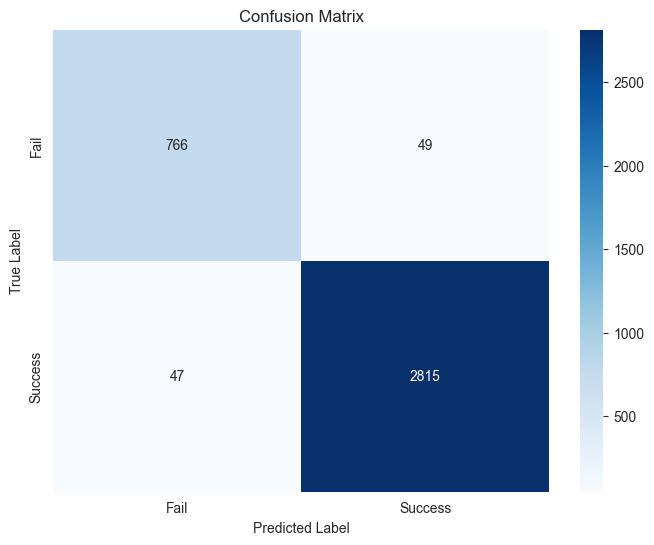

In [24]:
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# --- Visual Evaluation: Confusion Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [26]:
y_score = torch.cat(all_scores).numpy().ravel()
y_true  = torch.cat(all_labels).numpy().ravel()

pr_auc = average_precision_score(y_true, y_score)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9863374940085369
